In [134]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [135]:
import numpy as np
import torch

np.random.seed(0)
torch.manual_seed(0)

In [136]:
from tslearn.datasets import UCR_UEA_datasets

# Load dataset (Replace 'DatasetName' with your actual dataset)
ucr = UCR_UEA_datasets(use_cache=True)
X_train, y_train, X_test, y_test = ucr.load_dataset(
    "UWaveGestureLibrary"
)  # Good dataset : Epilepsy, UWaveGestureLibrary, HandMovementDirection

X_train.shape

(120, 315, 3)

In [137]:
y_train = y_train.astype(float).astype(int)
y_test = y_test.astype(float).astype(int)

In [138]:
import sys

sys.path.append("..")

In [147]:
from torch_mas.batch.trainer import BaseTrainer
from torch_mas.batch.internal_model import NClass
from torch_mas.batch.activation_function import BaseActivation
from torch_mas.data import DataBuffer
from torch_mas.batch.trainer.learning_rules import (
    IfNoActivated,
    IfNoActivatedAndNoNeighbors,
    IfActivated,
    SimpleDestroy,
)

_, seq_len, input_dim = X_train.shape

internal_nodel = NClass(
    input_dim=input_dim,
    output_dim=1,
    memory_length=input_dim + 1,
)

activation = BaseActivation(
    seq_len=seq_len,
    input_dim=input_dim,
    output_dim=1,
    alpha=1e-5,
)

trainer = BaseTrainer(
    activation,
    internal_nodel,
    kernel_size=[20, 40, 80],
    R=0.5,
    bad_th=0.1,
    n_epochs=100,
    batch_size=16,
    learning_rules=[
        IfNoActivatedAndNoNeighbors(),
        IfNoActivated(),
        IfActivated(),
        SimpleDestroy(5000),
    ],
)
dataset = DataBuffer(X_train, y_train)

trainer.fit(dataset)
trainer.n_agents

119

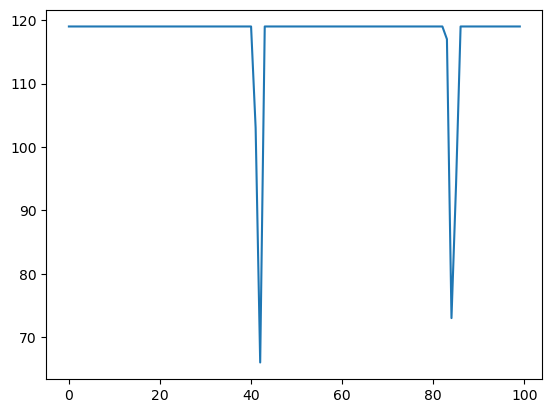

In [148]:
import matplotlib.pyplot as plt

plt.plot(trainer.agents_over_epoch)

In [143]:
import torch
from sklearn.metrics import accuracy_score

y_pred = trainer.predict(torch.tensor(X_test, dtype=torch.float32))
print(accuracy_score(y_pred[~torch.isnan(y_pred)], y_test[~torch.isnan(y_pred)]))

0.471875


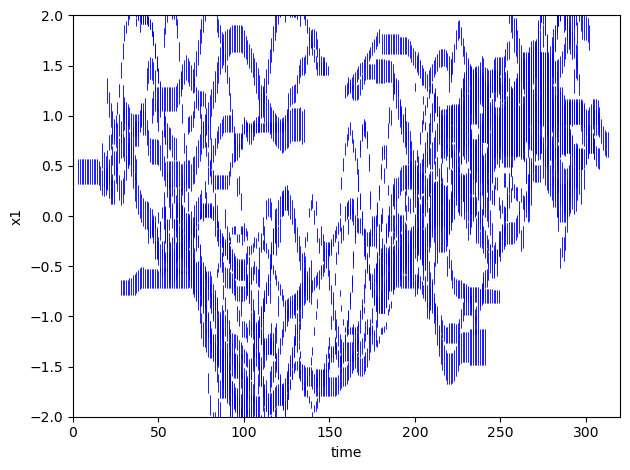

In [144]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches


fig, ax = plt.subplots()
colors = ["red", "blue", "green", "purple", "orange", "grey", "magenta", "brown"]

# activation.orthotopes is a tensor of size (n_agents, seq_len, n_dim, 2)
orthotopesdim0 = activation.orthotopes[:, :, 1, :]

for agent_id in range(orthotopesdim0.shape[0]):
    y = internal_nodel.base_prediction[agent_id]
    # print(y, colors[int(y - 1)])
    if y == 2:
        lines = []
        for time in range(orthotopesdim0[agent_id].shape[0]):
            if activation.timesteps[agent_id][time]:
                for h in range(orthotopesdim0[agent_id][time].shape[0]):
                    lines.append(
                        [
                            (time, orthotopesdim0[agent_id][time][0]),
                            (time, orthotopesdim0[agent_id][time][1]),
                        ]
                    )

        lc = LineCollection(lines, colors=colors[int(y - 1)], linewidths=0.5, alpha=0.9)
        ax.add_collection(lc)

ax.set_ylim(-2, 2)
ax.set_xlim(0, 320)
plt.xlabel("time")
plt.ylabel("x1")
plt.tight_layout()
plt.show()

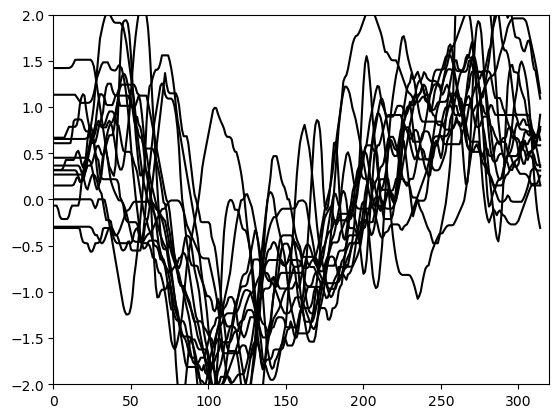

In [ ]:
import matplotlib.pyplot as plt

for l in X_train[y_train == 2][:, :, 1]:
    plt.plot(l, "black")

plt.ylim(-2, 2)
plt.xlim(0, 320)
plt.show()